# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Saffira Arentsen
* Username: sarentsen
* Student number: s6239145
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

Error propagation
$$g=\frac{4\pi^2 L}{T^2}$$
Using the following equation to find the error for g:
$$\sigma_g =\sqrt{(\frac{\partial{g}}{\partial{L}}\sigma_L)^2 + (\frac{\partial{g}}{\partial{T}}\sigma_T)^2} $$
$$\frac{\partial{g}}{\partial{L}}=\frac{4\pi^2}{T^2}$$
$$\frac{\partial{g}}{\partial{T}}=\frac{-8\pi^2 L}{T^3}$$
$$\sigma_g =\sqrt{(\frac{4\pi^2}{T^2}\sigma_L)^2 + (\frac{-8\pi^2 L}{T^3}\sigma_T)^2}$$

In [2]:
from scipy.constants import pi
import numpy as np

# Calculating g
L = 1.00
sigma_L = 0.01
T = 2.01
sigma_T = 0.02
def calc_g(L, T):
    '''Calculates gravitational acceleration g from pendulum length L and oscillation period T'''
    return 4*pi**2*L / T**2
g = calc_g(L, T)
# Calculating the error for g from given equation
sigma_g = np.sqrt((sigma_L*4*pi**2/T**2)**2+(sigma_T*-8*pi**2*L/T**3)**2)
print(f'Calculated g: {g:.2f}±{sigma_g:.2f} m/s^2')

# Monte Carlo, calculating the value and error for g again
N = 10000
L_array = np.random.normal(1.00, 0.01, N)
T_array = np.random.normal(2.01, 0.02, N)
g_array = calc_g(L_array, T_array)
print(f'Monte Carlo calculated g: {np.mean(g_array):.2f}±{np.std(g_array):.2f} m/s^2')

# In significant digits, the two results are equal, but Monte Carlo error propagation is faster/easier to write


Calculated g: 9.77±0.22 m/s^2
Monte Carlo calculated g: 9.77±0.22 m/s^2


In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [4]:
# print('Enter the values of a, b and c for the function: f(x)=ax^2+bx+c')
a = float(input('a: '))
b = float(input('b: '))
c = float(input('c: '))
def calc_sol(a, b, c):
    '''Returns the function, then a list of solutions for x, then the original equation worked out'''
    f =f'f(x)={a}x^2+{b}x+{c}'
    D = b**2 -4*a*c
    if D==0:x=[-b/(2*a)]
    else: x=[(-b+D**0.5)/(2*a), (-b-D**0.5)/(2*a)]
    example = []
    for i in x:
        sol = a*i**2+b*i+c
        an_example = f'f({i})={a}{i}^2+{b}{i}+{c} = {sol}'
        example.append(an_example)  
    return f, x, example

f, x, example = calc_sol(a, b, c)
for i in range(len(list(x))):
    print(f'function: {f}\nsolution {i+1}: {x[i]}\nexample {i+1}: {example[i]}')


a:  1
b:  2
c:  1


function: f(x)=1.0x^2+2.0x+1.0
solution 1: -1.0
example 1: f(-1.0)=1.0-1.0^2+2.0-1.0+1.0 = 0.0


In [5]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

Area between x=0 and x=2.5 is: 1.9769788548675902
Area between negative and positive infinity: 5.013256549262001 and 5.0132565492620005 (are the same).


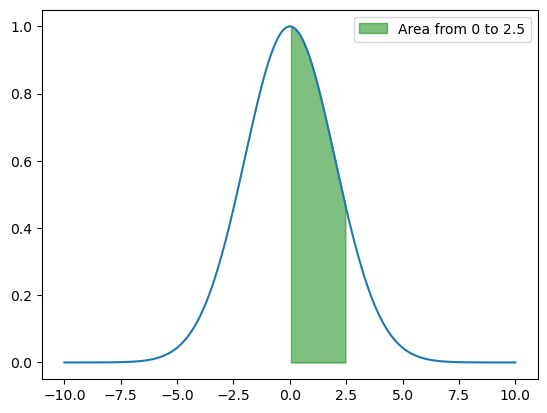

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.constants import pi

def gauss(x, A, x0, sigma, z0):
    '''Returns a one dimensional gauss function'''
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

x = np.linspace(-10, 10, 200)
A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0

area = quad(gauss, 0, 2.5, args=(A, x0, sig, z0))
print(f'Area between x=0 and x=2.5 is: {area[0]}')
area2 = quad(gauss, -np.inf, np.inf, args=(A, x0, sig, z0)) # Area found using quad
area3 = A*sig*np.sqrt(2*pi) # Area found from formula
print(f'Area between negative and positive infinity: {area2[0]} and {area3} (are the same).')

height = gauss(x, A, x0, sig, z0)
plt.plot(x, height)
plt.fill_between(x, height, where=(x >= 0) & (x <= 2.5), color='green', alpha=0.5, label='Area from 0 to 2.5')
plt.legend()
plt.show()

A:  1
x0:  0
sigma:  1
z0:  0
Lower integration limit:  0
Upper integration limit:  1


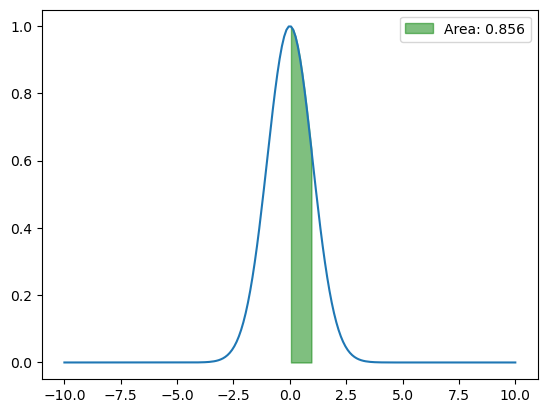

In [7]:
# Code for the script gaussarea.py
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.constants import pi

def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

x = np.linspace(-10, 10, 200)
A = float(input('A: '))
x0 = float(input('x0: '))
sig = float(input('sigma: '))
z0 = float(input('z0: '))
a = float(input('Lower integration limit: '))
b = float(input('Upper integration limit: '))

area = quad(gauss, a, b, args=(A, x0, sig, z0))

height = gauss(x, A, x0, sig, z0)
plt.plot(x, height)
plt.fill_between(x, height, where=(x >= a) & (x <= b), color='green', alpha=0.5, label=f'Area: {area[0]:.3f}')
plt.legend(loc='upper right')
plt.show()

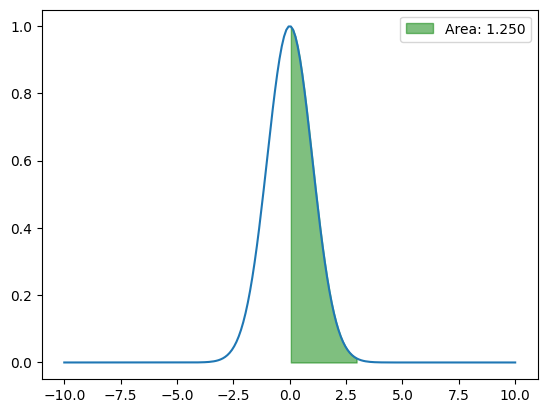

The generated plot is show in the markdown cell above and the script is uploaded to github: https://github.com/Firesapph/PROGNUM-repo/tree/main

In [8]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [9]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

In [10]:
import numpy as np
from numpy import sin, cos, exp, pi
from scipy.integrate import quad
a = 0
b = pi
f = 'x**4 + exp(sin(x)+cos(x))'
# Monte Carlo
def calc_integral(f, a, b, N=1000000):
    '''Calculates monte carlo integral from input function and input boundaries a and b'''
    x = np.random.uniform(a,b, N)
    f = eval(f)
    integral = (b-a) * np.mean(f)
    return integral

print(f'Monte Carlo integral: {calc_integral(f, a, b)}')
def func(x):
    '''Returns a function'''
    return x**4 + exp(sin(x)+cos(x))
print(f'quad integral: {quad(func, a, b)[0]}')

Monte Carlo integral: 68.76133388073885
quad integral: 68.72932272689113


In [11]:
# code for the script interate_user_function.py
import numpy as np
from numpy import sin, cos, exp, pi
from scipy.integrate import quad
f = input('Function you want to integrate: ')
try:
    a = eval(input('Lower limit: '))
    b = eval(input('Upper limit: '))
except (ValueError, NameError, TypeError):
    print('Please input a number, sin(), cos(), exp() or pi')

# Monte Carlo
def calc_integral(f, a, b, N=100000):
    '''Calculates monte carlo integral and quad integral from input function and input boundaries a and b'''
    try: 
        # Quad integral
        def func(x):
            return eval(f)
        quad_integral = quad(func, a, b)[0]

        # Monte Carlo integral
        x = np.random.uniform(a,b, N)
        monte_integral = (b-a) * np.mean(func(x))
        return monte_integral, quad_integral
    except (ValueError, TypeError): 
        print('Please type numbers or use x, sin(), cos(), exp() or pi')
        return (None, None)
    except SyntaxError:
        print('Please use correct syntax)')
        return (None, None)
    except OverflowError:
        print('The calculation was too large, the integral might be divergent or slowly convergent')
        return (None, None)

monte, quad = calc_integral(f, a, b)
print(f'Monte Carlo integral: {monte}')
print(f'quad integral: {quad}')

Function you want to integrate:  x
Lower limit:  0
Upper limit:  1


Monte Carlo integral: 0.49985210392956214
quad integral: 0.5


interate_user_function.py is uploaded to github: https://github.com/Firesapph/PROGNUM-repo/tree/main

In [12]:
# Sympy expression to calculate the integral
import sympy
from sympy import Symbol, sin, cos, exp, pi, integrate
x = Symbol('x')
f = x**4 + exp(sin(x)+cos(x))
intg = integrate(f, (x, 0, pi))
print(f'{intg} evaluated: {intg.evalf()}')

Integral(x**4 + exp(sin(x) + cos(x)), (x, 0, pi)) evaluated: 68.7293227268911


### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

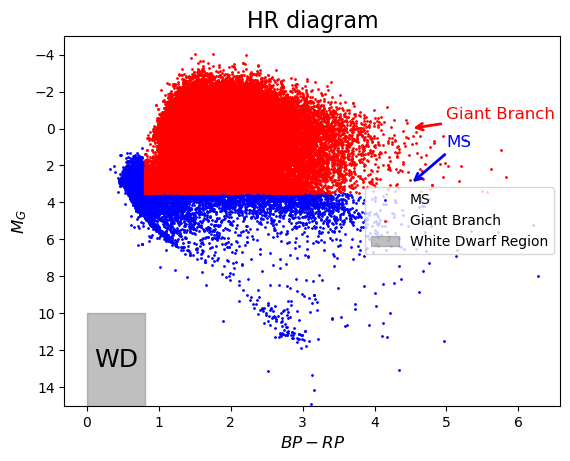

In [13]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names

# mask with True/False values based on requirements
mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    ((data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR']) > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)

# data that fulfill the requirements
good_data = data[mask]
# random 80 percent of data
random_indices = np.random.choice(len(good_data), size=int(len(good_data)*0.8), replace=False)
sample_data = good_data[random_indices]

colour = sample_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] - sample_data['GAIAEDR3_PHOT_RP_MEAN_MAG']
abs_magnitude = sample_data['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5 * np.log10(sample_data['GAIAEDR3_PARALLAX']/1000) + 5

giant_mask = (abs_magnitude < 3.5) & (colour > 0.8)

# Plotting MS and Giant Branch in HR diagram
plt.title('HR diagram', fontsize=16)
plt.scatter(colour[~giant_mask], abs_magnitude[~giant_mask], color='blue', s=1, label='MS')
plt.scatter(colour[giant_mask], abs_magnitude[giant_mask], color='red', s=1, label='Giant Branch')

'''I have many more data points compared to the shown plot on brightspace, it looks very ugly,
but I don't know how to get the plot to look like the one on brightspace'''

plt.xlabel(r'$BP-RP$', fontsize=12)
plt.ylabel(r"$M_G$", fontsize=12)
plt.gca().invert_yaxis()
plt.ylim(15, -5)
plt.yticks(np.arange(-4, 16, 2))

# Create WD rectangle in plot
x = [0, 0.8, 0.8, 0]
y = [15, 15, 10, 10]
plt.fill(x, y, color='grey', alpha=0.5, label="White Dwarf Region")
plt.text(0.4, (plt.ylim()[0] + 10) / 2, 'WD', fontsize=18, ha='center', va='center', color='black')

# arrow annotation (I didn't put them in the center, because then you can't see them)
plt.annotate(text='Giant Branch', xy=(4.5, 0.0), xytext=(5.0, -0.5), color='red', fontsize=12, 
             arrowprops=dict(arrowstyle = '->', linewidth=2,  color='red'))
plt.annotate(text='MS', xy=(4.5, 3), xytext=(5.0, 1), color='blue', fontsize=12,
             arrowprops=dict(arrowstyle = '->',linewidth=2, color='blue'))

plt.legend(loc='center right')
plt.show()

In [14]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [15]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 0.0.  Task Grade = 0.0
